# Customer Segmentation

Run clustering, build customer segments, and export segmentation outputs.


## Notebook Guide
This notebook runs the K-means segmentation workflow, evaluates candidate cluster counts, and turns the resulting groups into business-ready segment summaries.


In [26]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'dataset'
GENERATED_DIR = PROJECT_ROOT / 'generated'
FIGURES_DIR = PROJECT_ROOT / 'figures'

GENERATED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset dir: {DATA_DIR}')
print(f'Generated dir: {GENERATED_DIR}')
print(f'Figures dir: {FIGURES_DIR}')

import pandas as pd
customer_features = pd.read_csv(GENERATED_DIR / 'customer_features_prepared.csv')
pd.set_option('display.max_columns', None)
print(f"Loaded customer_features: {customer_features.shape}")


Project root: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis
Dataset dir: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/dataset
Generated dir: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/generated
Figures dir: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures
Loaded customer_features: (121112, 26)


## PART 5: CLUSTER MODELLING
Train the clustering model and inspect the geometry of the resulting customer groups.


In [27]:
# ============================================================================
# PART 5: CLUSTER MODELLING
# ============================================================================

print("\n" + "=" * 80)
print("PART 5: K-MEANS CLUSTERING")
print("=" * 80)



PART 5: K-MEANS CLUSTERING


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


def create_combinaison(customer_features, X_cols, method="mean"):
    print("\n[STEP 0] Creating 'combinaison' feature...")

    X_df = customer_features[X_cols].copy()
    X_df = X_df.select_dtypes(include=[np.number]).dropna()

    print(f"Using {len(X_df):,} rows to build 'combinaison'")
    print(f"X_cols = {X_cols}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    if method == "mean":
        combinaison = X_scaled.mean(axis=1)
    elif method == "sum":
        combinaison = X_scaled.sum(axis=1)
    else:
        raise ValueError("method must be either 'mean' or 'sum'")

    customer_features.loc[X_df.index, "combinaison"] = combinaison

    print("✓ 'combinaison' created")

    return customer_features, scaler


def determine_optimal_clusters(customer_features, profile_metrics, combinaison="combinaison"):
    print("\n[STEP 1] Determining optimal number of clusters...")

    features_to_use = profile_metrics.copy()
    if combinaison not in features_to_use:
        features_to_use.append(combinaison)

    existing = [c for c in features_to_use if c in customer_features.columns]
    missing = [c for c in features_to_use if c not in customer_features.columns]
    if missing:
        print(f"⚠ Missing columns (ignored): {missing}")

    X_df = customer_features[existing].select_dtypes(include=[np.number]).copy()
    X_df = X_df.dropna()

    used_features = X_df.columns.tolist()
    print(f"Using {len(used_features)} features: {used_features}")
    print(f"Rows used for clustering: {len(X_df):,}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    k_range = range(2, 11)
    inertias, silhouette_scores, davies_bouldin_scores = [], [], []

    for k in k_range:
        print(f"  Testing k={k}...", end=" ")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = kmeans.fit_predict(X_scaled)

        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
        print("Done")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(list(k_range), inertias, "bo-")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia")
    axes[0].set_title("Elbow Method")
    axes[0].grid(True)

    axes[1].plot(list(k_range), silhouette_scores, "go-")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_title("Silhouette Score")
    axes[1].grid(True)

    axes[2].plot(list(k_range), davies_bouldin_scores, "ro-")
    axes[2].set_xlabel("Number of Clusters (k)")
    axes[2].set_ylabel("Davies-Bouldin Score")
    axes[2].set_title("Davies-Bouldin Score")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

    optimal_k_silhouette = list(k_range)[int(np.argmax(silhouette_scores))]
    optimal_k_db = list(k_range)[int(np.argmin(davies_bouldin_scores))]

    print("\nRecommended number of clusters:")
    print(f"  Based on Silhouette Score: k={optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
    print(f"  Based on Davies-Bouldin Score: k={optimal_k_db} (score: {min(davies_bouldin_scores):.3f})")

    return {
        "X_df": X_df,
        "used_features": used_features,
        "scaler": scaler,
        "X_scaled": X_scaled,
        "k_range": list(k_range),
        "inertias": inertias,
        "silhouette_scores": silhouette_scores,
        "davies_bouldin_scores": davies_bouldin_scores,
        "optimal_k_silhouette": optimal_k_silhouette,
        "optimal_k_db": optimal_k_db,
    }


def final_clustering(customer_features, profile_metrics, combinaison, optimal_k):
    print(f"\n[STEP 2] Performing final clustering with k={optimal_k}...")

    features_to_use = profile_metrics.copy()
    if combinaison not in features_to_use:
        features_to_use.append(combinaison)

    existing = [c for c in features_to_use if c in customer_features.columns]
    missing = [c for c in features_to_use if c not in customer_features.columns]
    if missing:
        print(f"⚠ Missing columns (ignored): {missing}")

    df_clustering = customer_features[existing].select_dtypes(include=[np.number]).copy()
    df_clustering = df_clustering.dropna()

    used_features = df_clustering.columns.tolist()

    print(f"Using {len(used_features)} features: {used_features}")
    print(f"Rows used for clustering: {len(df_clustering):,}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clustering)

    kmeans_final = KMeans(
        n_clusters=optimal_k,
        random_state=42,
        n_init=20,
        max_iter=500
    )

    df_clustering["Cluster"] = kmeans_final.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, df_clustering["Cluster"])
    db_score = davies_bouldin_score(X_scaled, df_clustering["Cluster"])

    print("✓ Clustering complete")
    print(f"  Silhouette Score: {sil_score:.3f}")
    print(f"  Davies-Bouldin Score: {db_score:.3f}")

    cluster_counts = df_clustering["Cluster"].value_counts().sort_index()
    cluster_percentages = (
        df_clustering["Cluster"].value_counts(normalize=True).sort_index() * 100
    ).round(2)

    print("\nCluster distribution:")
    print(cluster_counts)

    print("\nCluster percentages:")
    print(cluster_percentages)

    return {
        "df_clustering": df_clustering,
        "used_features": used_features,
        "scaler": scaler,
        "X_scaled": X_scaled,
        "kmeans_final": kmeans_final,
        "silhouette_score": sil_score,
        "davies_bouldin_score": db_score,
        "cluster_counts": cluster_counts,
        "cluster_percentages": cluster_percentages,
    }


def plot_pca_clusters(X_scaled, df_clustering, optimal_k, cluster_col="Cluster"):
    print("\n[STEP 3] Creating PCA visualization...")

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=df_clustering[cluster_col],
        cmap="viridis",
        alpha=0.6,
        s=50
    )

    plt.xlabel(f"First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.title(f"Customer Segments Visualization (k={optimal_k})")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

    explained_variance = pca.explained_variance_ratio_[:2].sum()
    print(f"PCA explained variance (2 components): {explained_variance:.1%}")

    return {
        "pca": pca,
        "X_pca": X_pca,
        "explained_variance_2d": explained_variance
    }


def clustering_pipeline(customer_features, X_cols, all_metrics, combinaison_method="mean"):
    print("\n========== CLUSTERING PIPELINE ==========")

    profile_metrics = [col for col in all_metrics if col not in X_cols]

    print("X_cols =", X_cols)
    print("profile_metrics =", profile_metrics)

    customer_features, scaler_comb = create_combinaison(
        customer_features=customer_features,
        X_cols=X_cols,
        method=combinaison_method
    )

    k_results = determine_optimal_clusters(
        customer_features=customer_features,
        profile_metrics=profile_metrics,
        combinaison="combinaison"
    )

    print("\nTu peux maintenant choisir k.")
    print(f"Suggestion silhouette: {k_results['optimal_k_silhouette']}")
    print(f"Suggestion Davies-Bouldin: {k_results['optimal_k_db']}")

    optimal_k = int(k_results.get("optimal_k_silhouette", 4))
    print(f"Using optimal_k={optimal_k} based on silhouette suggestion")

    clustering_results = final_clustering(
        customer_features=customer_features,
        profile_metrics=profile_metrics,
        combinaison="combinaison",
        optimal_k=optimal_k
    )

    pca_results = plot_pca_clusters(
        X_scaled=clustering_results["X_scaled"],
        df_clustering=clustering_results["df_clustering"],
        optimal_k=optimal_k,
        cluster_col="Cluster"
    )

    return {
        "customer_features": customer_features,
        "profile_metrics": profile_metrics,
        "scaler_comb": scaler_comb,
        "k_results": k_results,
        "optimal_k": optimal_k,
        "clustering_results": clustering_results,
        "pca_results": pca_results
    }


## STEP 1: Define the modelling variables and evaluate candidate values of k
Build the modelling matrix and compare several cluster counts before fixing the final choice.


X_cols = ['transactions_per_month', 'avg_basket_value', 'recency_days']
profile_metrics = ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score']

[STEP 0] Creating 'combinaison' feature...
Using 121,112 rows to build 'combinaison'
X_cols = ['transactions_per_month', 'avg_basket_value', 'recency_days']
✓ 'combinaison' created

[STEP 1] Determining optimal number of clusters...
Using 6 features: ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Rows used for clustering: 121,112
  Testing k=2... Done
  Testing k=3... Done
  Testing k=4... Done
  Testing k=5... Done
  Testing k=6... Done
  Testing k=7... Done
  Testing k=8... Done
  Testing k=9... Done
  Testing k=10... Done


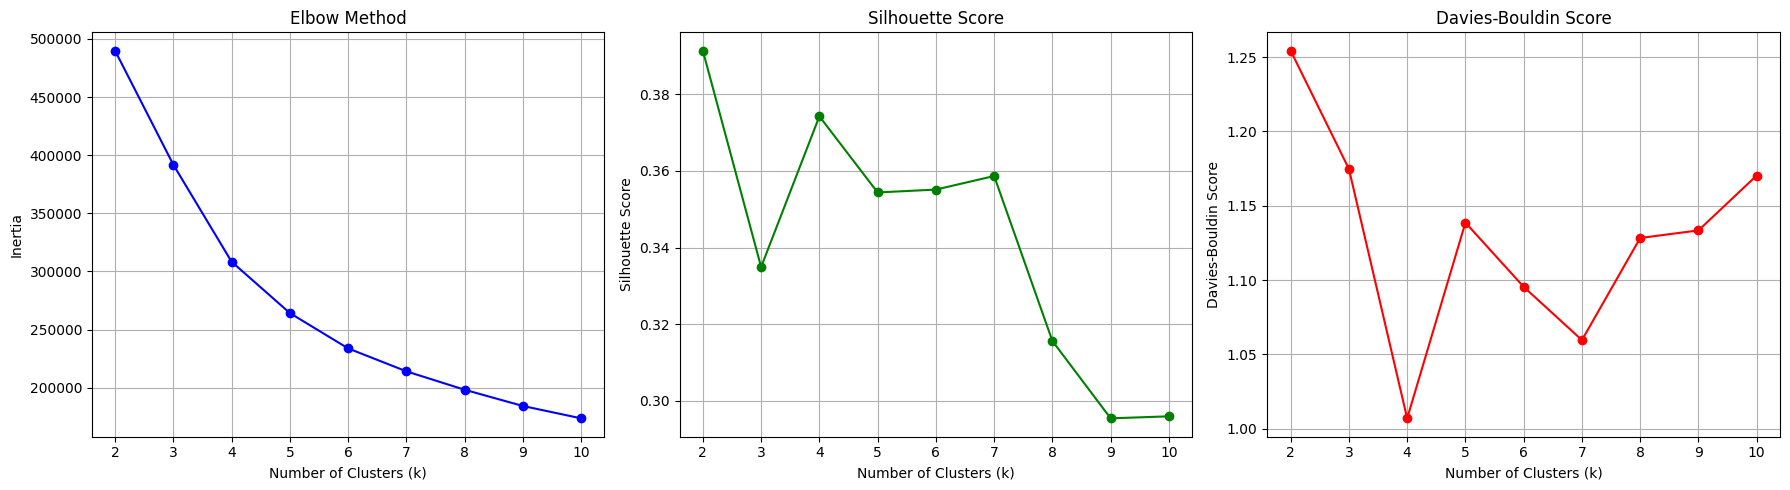


Recommended number of clusters:
  Based on Silhouette Score: k=2 (score: 0.391)
  Based on Davies-Bouldin Score: k=4 (score: 1.007)


In [29]:
# ============================================================================
# STEP 1: Define the modelling variables and evaluate candidate values of k
# ============================================================================

all_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
]

X_cols = ["transactions_per_month", "avg_basket_value", "recency_days"]

profile_metrics = [col for col in all_metrics if col not in X_cols]

print("X_cols =", X_cols)
print("profile_metrics =", profile_metrics)

# 1) créer combinaison
customer_features, scaler_comb = create_combinaison(
    customer_features=customer_features,
    X_cols=X_cols,
    method="mean"
)

# 2) afficher les métriques pour choisir k
k_results = determine_optimal_clusters(
    customer_features=customer_features,
    profile_metrics=profile_metrics,
    combinaison="combinaison"
)


## STEP 2: Run the final clustering model and project it with PCA
Fit the selected model configuration and create a two-dimensional view for interpretation.



[STEP 2] Performing final clustering with k=4...
Using 6 features: ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Rows used for clustering: 121,112
✓ Clustering complete
  Silhouette Score: 0.374
  Davies-Bouldin Score: 1.006

Cluster distribution:
Cluster
0    62627
1     6925
2    17509
3    34051
Name: count, dtype: int64

Cluster percentages:
Cluster
0    51.71
1     5.72
2    14.46
3    28.12
Name: proportion, dtype: float64

[STEP 3] Creating PCA visualization...


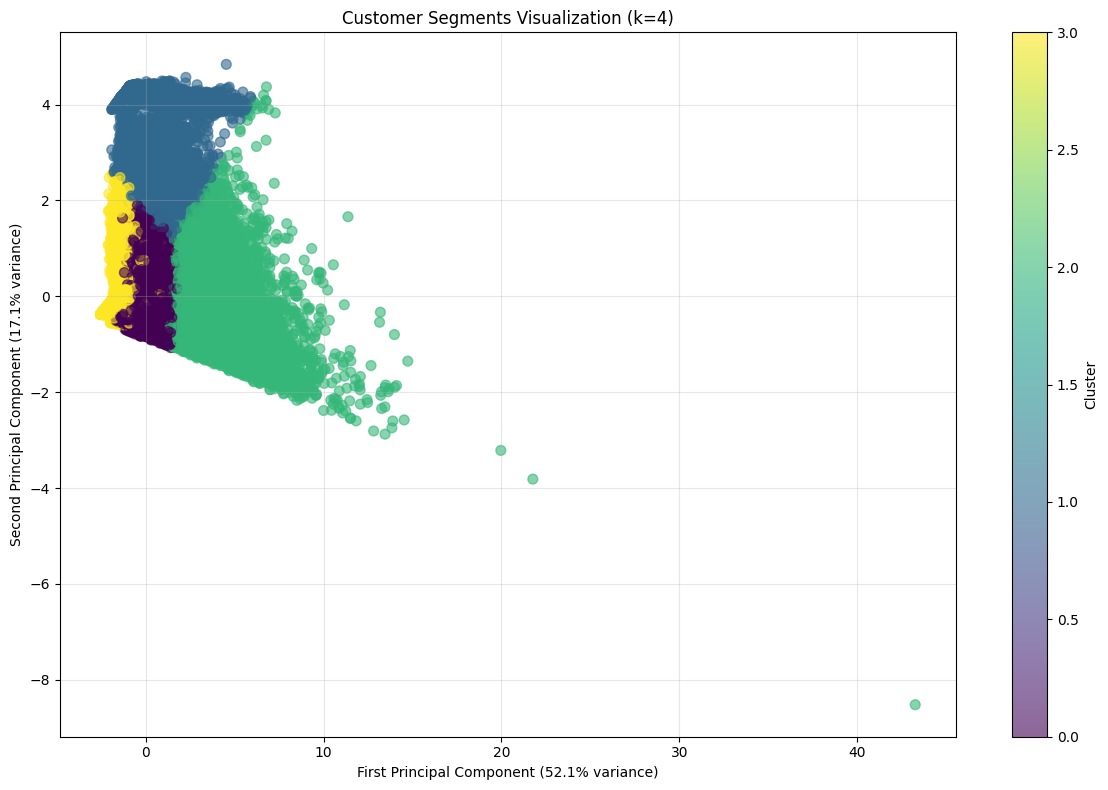

PCA explained variance (2 components): 69.2%
        CD_TICKET_UNIQUE_total_transactions  MT_TTC_NET_total_spend  \
0                                         2                   26.59   
1                                         4                   71.55   
2                                         1                   37.04   
3                                         2                   49.39   
4                                         1                   21.98   
...                                     ...                     ...   
121107                                    1                    2.47   
121108                                    1                    1.19   
121109                                    2                   18.81   
121110                                    1                   12.46   
121111                                    2                   28.31   

        promo_percentage  product_diversity_score  store_loyalty_score  \
0              18.128717    

In [30]:
# ============================================================================
# STEP 2: Run the final clustering model and project it with PCA
# ============================================================================

chosen_k = 4

clustering_results = final_clustering(
    customer_features=customer_features,
    profile_metrics=profile_metrics,
    combinaison="combinaison",
    optimal_k=chosen_k
)

df_clustering = clustering_results["df_clustering"]

pca_results = plot_pca_clusters(
    X_scaled=clustering_results["X_scaled"],
    df_clustering=df_clustering,
    optimal_k=chosen_k,
    cluster_col="Cluster"
)

print(df_clustering)


In [31]:
df_clustering.columns


Index(['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend',
       'promo_percentage', 'product_diversity_score', 'store_loyalty_score',
       'combinaison', 'Cluster'],
      dtype='str')

## PART 6: SEGMENT CHARACTERIZATION (merge clusters back)
Join the cluster labels back to the customer table so each segment can be profiled in business terms.


In [32]:
# ============================================================================
# PART 6: SEGMENT CHARACTERIZATION (merge clusters back)
# ============================================================================

print("\n" + "=" * 80)
print("PART 6: SEGMENT CHARACTERIZATION")
print("=" * 80)

id_col = "NO_TOKEN"

if id_col not in customer_features.columns:
    raise KeyError(f"'{id_col}' not found in customer_features")

# `df_clustering` is often created without the identifier because the model uses numeric features only.
if id_col not in df_clustering.columns:
    cluster_map = customer_features.loc[df_clustering.index, [id_col]].copy()
    cluster_map["Cluster"] = df_clustering["Cluster"].values
else:
    cluster_map = df_clustering[[id_col, "Cluster"]].copy()

customer_segments = customer_features.merge(
    cluster_map,
    on=id_col,
    how="left"
)

print("✓ Merge done")
print("  Rows:", len(customer_segments))
print("  Unassigned clusters:", int(customer_segments["Cluster"].isna().sum()))

customer_segments.to_csv(GENERATED_DIR / "customers_with_segments.csv", index=False)
print("✓ Saved customer-level segments to 'customers_with_segments.csv'")



PART 6: SEGMENT CHARACTERIZATION
✓ Merge done
  Rows: 121112
  Unassigned clusters: 0
✓ Saved customer-level segments to 'customers_with_segments.csv'


In [33]:
print("\nCluster distribution:")
print(customer_segments["Cluster"].value_counts(normalize=True).sort_index().round(4))



Cluster distribution:
Cluster
0    0.5171
1    0.0572
2    0.1446
3    0.2812
Name: proportion, dtype: float64


## STEP 6.1: Statistical Segment Profiles (mean + count + %)
Summarize the average behavior, size, and share of each segment.


In [34]:
# ============================================================================
# STEP 6.1: Statistical Segment Profiles (mean + count + %)
# ============================================================================

print("\n[STEP 6.1] Creating segment profiles...")

profile_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
    "combinaison",  # Include the engineered summary feature created for clustering.
]

# Keep only the metrics that are available in the current dataset.
profile_metrics = [m for m in profile_metrics if m in customer_segments.columns]

# Confirm that the cluster label exists before profiling the segments.
if "Cluster" not in customer_segments.columns:
    raise KeyError("'Cluster' not found in customer_segments")

# Segment profiles (mean)
segment_profiles = customer_segments.groupby("Cluster")[profile_metrics].mean()

# Ajouter volume et pourcentage
cluster_counts = customer_segments["Cluster"].value_counts().sort_index()
cluster_pct = (customer_segments["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2)

segment_profiles = segment_profiles.join(cluster_counts.rename("n")).join(cluster_pct.rename("pct"))

print("\nSegment Profiles (Mean values):")
print("=" * 100)
print(segment_profiles.round(2))

# Save to CSV
segment_profiles.to_csv(GENERATED_DIR / "segment_profiles.csv")
print("✓ Saved segment profiles to 'segment_profiles.csv'")



[STEP 6.1] Creating segment profiles...

Segment Profiles (Mean values):
         recency_days  CD_TICKET_UNIQUE_total_transactions  \
Cluster                                                      
0                8.34                                 1.28   
1               16.06                                 1.24   
2                5.80                                 2.66   
3                9.30                                 1.13   

         MT_TTC_NET_total_spend  avg_basket_value  transactions_per_month  \
Cluster                                                                     
0                         32.15             27.38                    1.17   
1                         38.65             32.46                    1.13   
2                        111.29             58.88                    1.95   
3                         14.88             13.30                    1.08   

         promo_percentage  product_diversity_score  store_loyalty_score  \
Cluster        

## STEP 6.2: Segment Naming and Characterization (Radar charts)
Visualize each segment’s relative strengths and weaknesses across the main metrics.



[STEP 6.2] Characterizing segments...


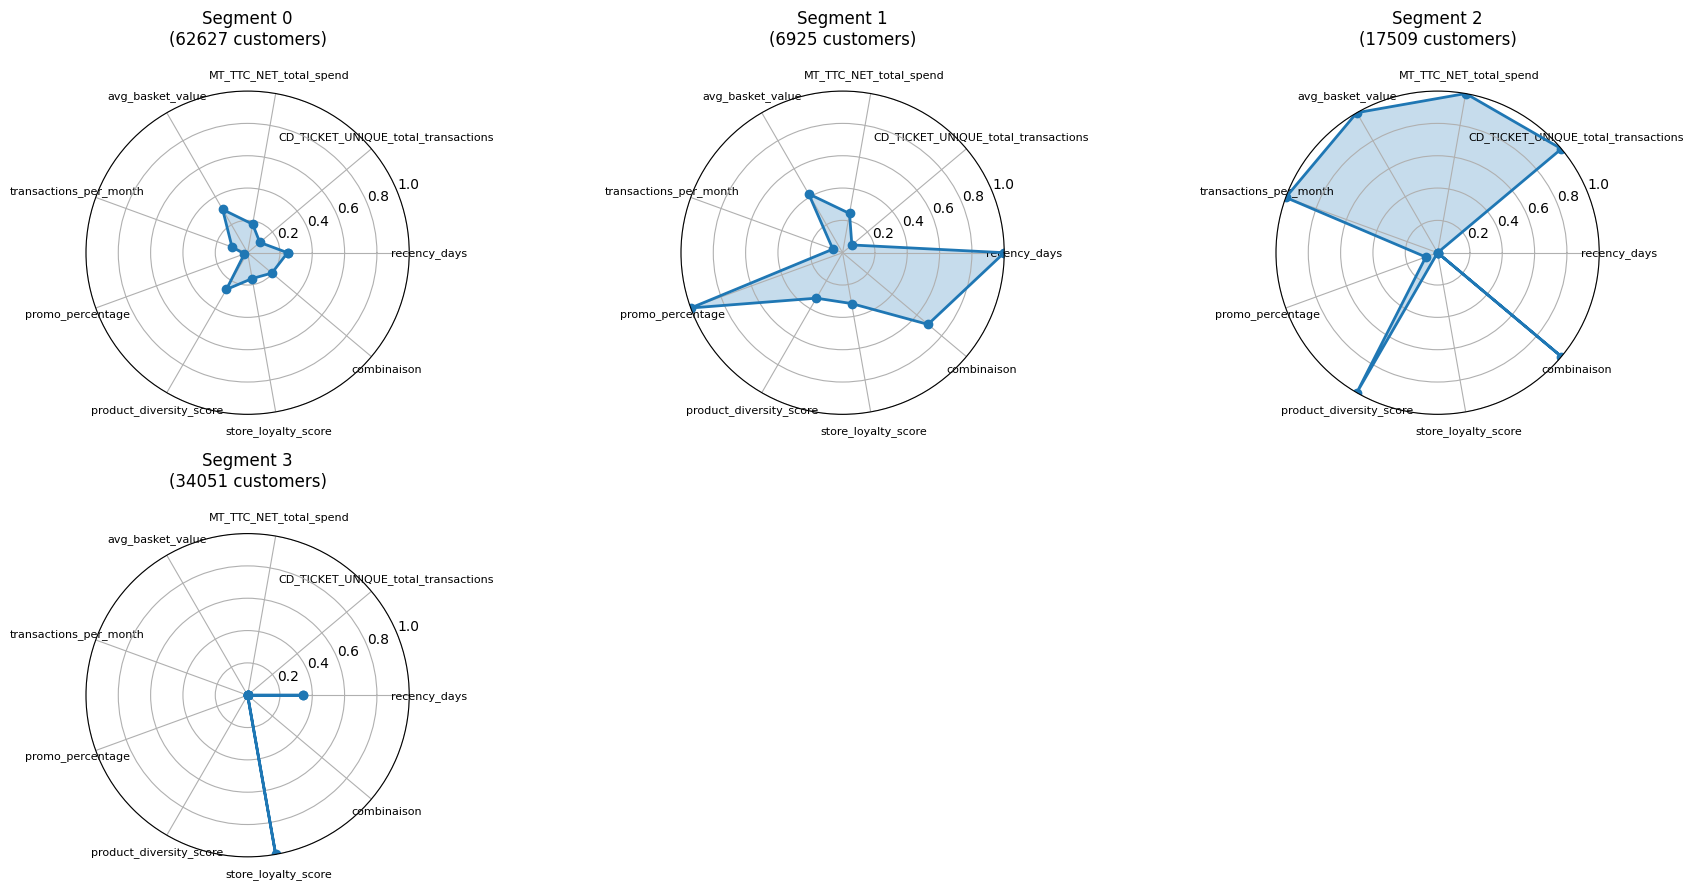

✓ Segment radar charts saved as 'segment_radar_charts.png'


In [35]:
# ============================================================================
# STEP 6.2: Segment Naming and Characterization (Radar charts)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n[STEP 6.2] Characterizing segments...")

# Select the metrics to plot and exclude purely descriptive count columns.
# Count and percentage columns are excluded because they do not belong on the radar scale.
plot_metrics = [c for c in segment_profiles.columns if c not in ["n", "pct"]]

# Create the angular positions for the radar chart axes.
angles = np.linspace(0, 2 * np.pi, len(plot_metrics), endpoint=False).tolist()
angles += angles[:1]

# Build a subplot grid large enough to display every segment.
optimal_k = 4
n_clusters = int(optimal_k)
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
    subplot_kw=dict(projection="polar")
)

# Flatten the axes array so the plotting loop works for both one-row and multi-row layouts.
axes = np.array(axes).reshape(-1)

# Normalize each metric across clusters so the radar shapes can be compared on the same 0-1 scale.
mins = segment_profiles[plot_metrics].min(axis=0)
maxs = segment_profiles[plot_metrics].max(axis=0)
den = (maxs - mins).replace(0, np.nan)  # éviter division par 0

for idx, cluster_id in enumerate(sorted(segment_profiles.index.tolist())):
    if idx >= len(axes):
        break
    ax = axes[idx]

    # Plot the normalized profile for the current cluster.
    values = segment_profiles.loc[cluster_id, plot_metrics]
    values_norm = ((values - mins) / den).fillna(0.0).values.tolist()
    values_norm += values_norm[:1]

    ax.plot(angles, values_norm, "o-", linewidth=2)
    ax.fill(angles, values_norm, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(plot_metrics, size=8)
    ax.set_ylim(0, 1)

    n_customers = int(customer_segments["Cluster"].eq(cluster_id).sum())
    ax.set_title(f"Segment {cluster_id}\n({n_customers} customers)", size=12, pad=18)
    ax.grid(True)

# Remove unused subplot slots when the grid is larger than the number of clusters.
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "segment_radar_charts.png", dpi=300, bbox_inches="tight")  # save BEFORE show
plt.show()
print("✓ Segment radar charts saved as 'segment_radar_charts.png'")
plt.close()


## STEP 6.3: Business Insights Summary (adapted)
Translate the statistical profiles into a concise operating summary for decision-makers.


In [36]:
# ============================================================================
# STEP 6.3: Business Insights Summary (adapted)
# ============================================================================

print("\n[STEP 6.3] Generating business insights...")

# Build the aggregation spec dynamically so the summary still runs if some columns are absent.
id_col = "NO_TOKEN_CB"
agg_spec = {}

if id_col in customer_segments.columns:
    agg_spec[id_col] = "count"

if "MT_TTC_NET_total_spend" in customer_segments.columns:
    agg_spec["MT_TTC_NET_total_spend"] = ["sum", "mean"]

if "CD_TICKET_UNIQUE_total_transactions" in customer_segments.columns:
    agg_spec["CD_TICKET_UNIQUE_total_transactions"] = "mean"

if "recency_days" in customer_segments.columns:
    agg_spec["recency_days"] = "mean"

if "promo_percentage" in customer_segments.columns:
    agg_spec["promo_percentage"] = "mean"

if "store_loyalty_score" in customer_segments.columns:
    agg_spec["store_loyalty_score"] = "mean"

if "combinaison" in customer_segments.columns:
    agg_spec["combinaison"] = "mean"

if "Cluster" not in customer_segments.columns:
    raise KeyError("'Cluster' not found in customer_segments")

segment_summary = customer_segments.groupby("Cluster").agg(agg_spec).round(2)

# Flatten the multi-index columns produced by grouped aggregations.
segment_summary.columns = [
    "_".join([str(x) for x in col if x]).strip("_") if isinstance(col, tuple) else col
    for col in segment_summary.columns
]

# Apply clearer business-facing labels where those aggregates exist.
rename_map = {
    id_col: "Customer_Count",
    "MT_TTC_NET_total_spend_sum": "Total_Revenue",
    "MT_TTC_NET_total_spend_mean": "Avg_Revenue_Per_Customer",
    "CD_TICKET_UNIQUE_total_transactions": "Avg_Transactions",
    "recency_days": "Avg_Recency",
    "promo_percentage": "Avg_Promo_%",
    "store_loyalty_score": "Avg_Store_Loyalty",
    "combinaison": "Avg_Combinaison",
}
segment_summary = segment_summary.rename(columns={k: v for k, v in rename_map.items() if k in segment_summary.columns})

# Express each segment's revenue contribution as a percentage of total revenue.
if "Total_Revenue" in segment_summary.columns:
    segment_summary["Revenue_%"] = (
        segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100
    ).round(2)

print("\nSegment Business Summary:")
print("=" * 120)
print(segment_summary)

# Save results
segment_summary.to_csv(GENERATED_DIR / "segment_business_summary.csv")
print("✓ Saved business summary to 'segment_business_summary.csv'")



[STEP 6.3] Generating business insights...

Segment Business Summary:
         Total_Revenue  Avg_Revenue_Per_Customer  \
Cluster                                            
0           2013686.83                     32.15   
1            267636.18                     38.65   
2           1948643.84                    111.29   
3            506645.80                     14.88   

         CD_TICKET_UNIQUE_total_transactions_mean  recency_days_mean  \
Cluster                                                                
0                                            1.28               8.34   
1                                            1.24              16.06   
2                                            2.66               5.80   
3                                            1.13               9.30   

         promo_percentage_mean  store_loyalty_score_mean  combinaison_mean  \
Cluster                                                                      
0                         4

In [37]:
print("\n" + "=" * 80)
print("CLUSTERING ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nSegments created: {optimal_k}")
print(f"Total customers segmented: {len(customer_segments)}")
print("\nKey outputs generated:")
print("  1. feature_distributions.png")
print("  2. correlation_matrix.png")
print("  3. rfm_analysis.png")
print("  4. clustering_metrics.png")
print("  5. cluster_visualization_pca.png")
print("  6. segment_radar_charts.png")
print("  7. segment_profiles.csv")
print("  8. segment_business_summary.csv")
print("  9. customers_with_segments.csv")
print("\nProceeding to association rules and recommendations!")



CLUSTERING ANALYSIS COMPLETE!

Segments created: 4
Total customers segmented: 121112

Key outputs generated:
  1. feature_distributions.png
  2. correlation_matrix.png
  3. rfm_analysis.png
  4. clustering_metrics.png
  5. cluster_visualization_pca.png
  6. segment_radar_charts.png
  7. segment_profiles.csv
  8. segment_business_summary.csv
  9. customers_with_segments.csv

Proceeding to association rules and recommendations!


## Results Summary

- Evaluated candidate values of `k`, ran the final K-means segmentation, and projected the result into PCA space for visualization.
- Assigned every customer to a segment and produced statistical profiles, radar charts, and a business summary for the final clusters.
- Saved the segment labels and segment-level rollups needed by the downstream rule-mining notebooks.
- Main outputs: `generated/customers_with_segments.csv`, `generated/segment_profiles.csv`, `generated/segment_business_summary.csv`, and `figures/segment_radar_charts.png`.
